In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YOLO-Kaggle-Results-Val

In [2]:
#### YOLO-Kaggle-Results-Val

data_kaggle_yolo_val = [{
    "Fold": 1,
    "Precision": 0.998,
    "Recall": 1,
    "mAP50": 0.995,
    "mAP50-95": 0.821
},
{
    "Fold": 2,
    "Precision": 0.998,
    "Recall": 1,
    "mAP50": 0.995,
    "mAP50-95": 0.844
},
{
    "Fold": 3,
    "Precision": 0.997,
    "Recall": 0.967,
    "mAP50": 0.972,
    "mAP50-95": 0.798
},
{
    "Fold": 4,
    "Precision": 1,
    "Recall": 1,
    "mAP50": 0.995,
    "mAP50-95": 0.838
},
{
    "Fold": 5,
    "Precision": 0.997,
    "Recall": 1,
    "mAP50": 0.995,
    "mAP50-95": 0.822
}
]

yolo_kaggle_val_df = pd.DataFrame(data_kaggle_yolo_val)

num_cols = [col for col in yolo_kaggle_val_df if col != "Fold"]

yolo_kaggle_val_df.style.format("{:.3f}", subset=num_cols).hide(axis="index")

Fold,Precision,Recall,mAP50,mAP50-95
1,0.998,1.000,0.995,0.821
2,0.998,1.000,0.995,0.844
3,0.997,0.967,0.972,0.798
4,1.000,1.000,0.995,0.838
5,0.997,1.000,0.995,0.822


In [3]:
## YOLO-Kaggle-Results-Val Mean + Std

yolo_kaggle_val_df = round(yolo_kaggle_val_df.drop(columns="Fold").agg(["mean", "std"]).rename({"mean": "Mean", "std": "Std (+-)"}),3)

yolo_kaggle_val_df

,Precision,Recall,mAP50,mAP50-95
Mean,0.998,0.993,0.99,0.825
Std (+-),0.001,0.015,0.01,0.018


RF-DETR-Roboflow Results

RF-DETR-Kaggle 5-Fold-CV-Val

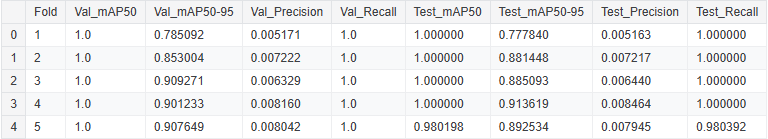

RF-DETR-Kaggle Results

Validation

In [4]:
### Validation RF-DETR-Kaggle

import pandas as pd

# Daten basierend auf dem Screenshot
data_val = {
    'Fold': [1, 2, 3, 4, 5],
    # Validation Daten
    'Precision': [1, 1, 1, 1, 1], ## from confusion, with Precision() its not quite right
    'Recall': [1.0, 1.0, 1.0, 1.0, 1.0],
    'mAP50': [1.0, 1.0, 1.0, 1.0, 1.0],
    'mAP50-95': [0.785670, 0.853004, 0.909271, 0.901233, 0.907649],
}


# Erstellen des gesamten DataFrames
df_val = pd.DataFrame(data_val)


num_cols_val = [col for col in df_val if col != "Fold"]


df_val.style.format("{:.3f}", subset=num_cols_val).hide(axis="index")


Fold,Precision,Recall,mAP50,mAP50-95
1,1.000,1.000,1.000,0.786
2,1.000,1.000,1.000,0.853
3,1.000,1.000,1.000,0.909
4,1.000,1.000,1.000,0.901
5,1.000,1.000,1.000,0.908


In [5]:
## RF-DETR Validation Mean + Std
summary_rfdetr_kaggle_val = df_val.drop(columns=['Fold']).agg(['mean', 'std'])

summary_rfdetr_kaggle_val = round(summary_rfdetr_kaggle_val.rename({"mean": "Mean", "std": "Std (+-)"}),3)
summary_rfdetr_kaggle_val

,Precision,Recall,mAP50,mAP50-95
Mean,1.0,1.0,1.0,0.871
Std (+-),0.0,0.0,0.0,0.053


Validation_Plotting

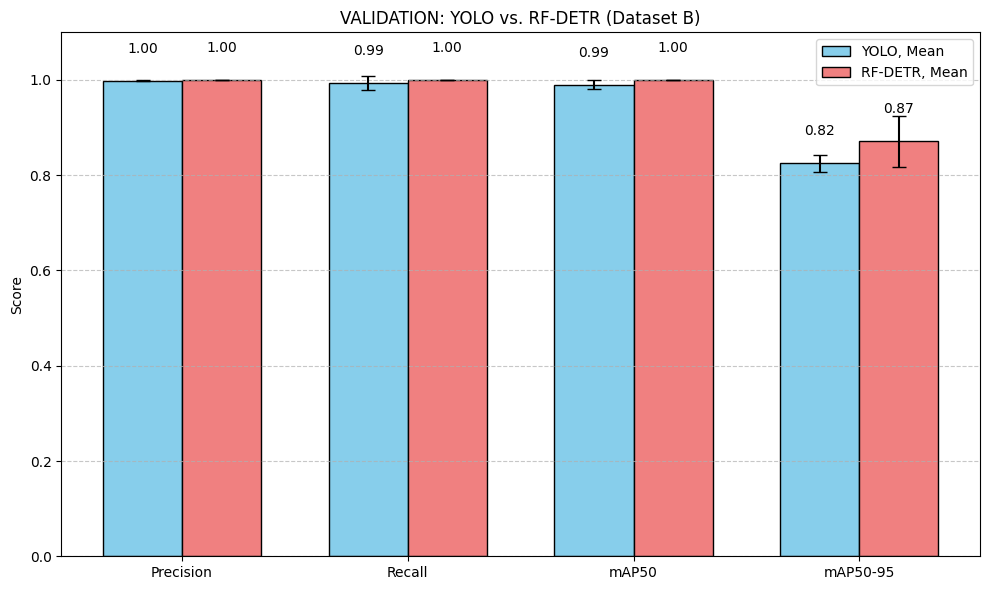

In [6]:
# 1. Daten in eine vergleichbare Struktur bringen
metrics = ["Precision",'Recall', 'mAP50', 'mAP50-95']

df_yolo_val = yolo_kaggle_val_df.T
df_rfdetr_val = summary_rfdetr_kaggle_val.T

# 2. Plotting vorbereiten
labels = df_yolo_val.index
x = np.arange(len(labels))  # Position der Labels auf der X-Achse
width = 0.35  # Breite der Balken

fig, ax = plt.subplots(figsize=(10, 6))

# Balken für Modell A (mit yerr für die Fehlerbalken aus 'Std(+-)')
rects1 = ax.bar(x - width/2, df_yolo_val["Mean"], width, label='YOLO, Mean', 
                yerr=df_yolo_val['Std (+-)'], capsize=5, color='skyblue', edgecolor='black')

# Balken für Modell B
rects2 = ax.bar(x + width/2, df_rfdetr_val['Mean'], width, label='RF-DETR, Mean', 
                yerr=df_rfdetr_val['Std (+-)'], capsize=5, color='lightcoral', edgecolor='black')

# 3. Design und Labels anpassen
ax.set_ylabel('Score')
ax.set_title('VALIDATION: YOLO vs. RF-DETR (Dataset B)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1) # Y-Achse etwas grösser als 1.0 für die Fehlerbalken
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Werte über den Balken anzeigen (optional)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 18),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()



RF-DETR-Kaggle 5-Fold-CV-Test

In [8]:
## RF-DETR-Kaggle Test

import pandas as pd


data_test = {
    'Fold': [1, 2, 3, 4, 5],
    'Precision': [0.986, 1, 1, 1, 1],
    'Recall': [1.000000, 1.000000, 1.000000, 1.000000, 0.980392],
    'mAP50': [1.000000, 1.000000, 1.000000, 1.000000, 0.980198],
    'mAP50-95': [0.777840, 0.881448, 0.885093, 0.913619, 0.892534]
}

df_test = pd.DataFrame(data_test)

df_test = df_test[['Fold', "Precision", "Recall", 'mAP50', 'mAP50-95']].copy()


num_cols_test = [col for col in df_test if col != "Fold"]

# Zusammenfassung berechnen

df_test.style.format("{:.3f}", subset=num_cols_test).hide(axis="index")

Fold,Precision,Recall,mAP50,mAP50-95
1,0.986,1.000,1.000,0.778
2,1.000,1.000,1.000,0.881
3,1.000,1.000,1.000,0.885
4,1.000,1.000,1.000,0.914
5,1.000,0.980,0.980,0.893


In [9]:
## RF-DETR-Kaggle Test Mean + Std

summary_test_rfdetr_kaggle = df_test.drop(columns=['Fold']).agg(['mean', 'std'])

summary_test_rfdetr_kaggle = round(summary_test_rfdetr_kaggle.rename({"mean": "Mean", "std": "Std (+-)"}),3)

summary_test_rfdetr_kaggle

,Precision,Recall,mAP50,mAP50-95
Mean,0.997,0.996,0.996,0.870
Std (+-),0.006,0.009,0.009,0.053


YOLO-Kaggle-Results-Test

In [10]:
### YOLO-Kaggle-Test

# Daten aus der Benutzereingabe
data = [
    {
        "Fold": 1,
        "Precision": 0.9772674114421703,
        "Recall": 1.0,
        "mAP50": 0.994592,
        "mAP50-95": 0.819206,
       
    },
    {
        "Fold": 2,
        "Precision": 0.9797221042867775,
        "Recall": 1.0,
        "mAP50": 0.994444,
        "mAP50-95": 0.831578
        
    },
    {
        "Fold": 3,
        "Precision": 1.0,
        "Recall": 0.9751540154585319,
        "mAP50": 0.994600,
        "mAP50-95": 0.788892
            
    },
    {
        "Fold": 4,
        "Precision": 0.9987336240133619,
        "Recall": 0.9615384615384616,
        "mAP50": 0.985325,
        "mAP50-95": 0.808739
   
    },
    {
        "Fold": 5,
        "Precision": 0.9994167272567542,
        "Recall": 1.0,
        "mAP50": 0.995000,
        "mAP50-95": 0.851857
        
    }
]


df = pd.DataFrame(data)

num_cols = [col for col in df if col != "Fold"]

df.style.format("{:.3f}", subset=num_cols).hide(axis="index")

Fold,Precision,Recall,mAP50,mAP50-95
1,0.977,1.000,0.995,0.819
2,0.980,1.000,0.994,0.832
3,1.000,0.975,0.995,0.789
4,0.999,0.962,0.985,0.809
5,0.999,1.000,0.995,0.852


In [11]:
### YOLO-Kaggle-Test Mean + Std


# Zusammenfassung berechnen
summary_yolo_kaggle_test = df.drop(columns=['Fold']).agg(['mean', 'std'])

summary_yolo_kaggle_test = round(summary_yolo_kaggle_test.rename({"mean": "Mean", "std": "Std (+-)"}),3)


summary_yolo_kaggle_test

,Precision,Recall,mAP50,mAP50-95
Mean,0.991,0.987,0.993,0.820
Std (+-),0.011,0.018,0.004,0.024


Testing_Plotting

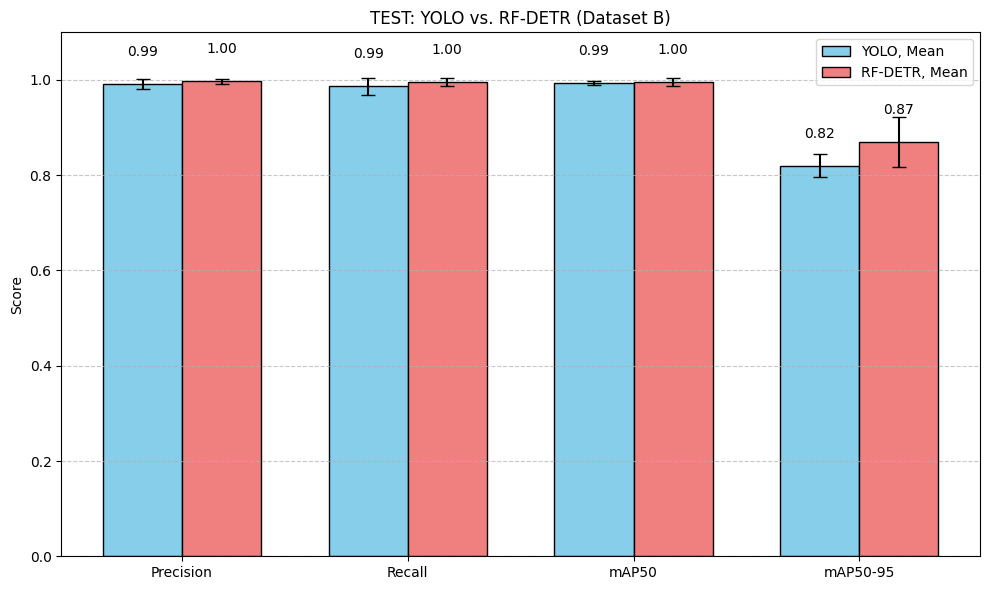

In [12]:
# 1. Daten in eine vergleichbare Struktur bringen
metrics = ["Precision",'Recall', 'mAP50', 'mAP50-95']

df_yolo_test = summary_yolo_kaggle_test.T
df_rfdetr_test = summary_test_rfdetr_kaggle.T

# 2. Plotting vorbereiten
labels = df_yolo_test.index
x = np.arange(len(labels))  # Position der Labels auf der X-Achse
width = 0.35  # Breite der Balken

fig, ax = plt.subplots(figsize=(10, 6))

# Balken für Modell A (mit yerr für die Fehlerbalken aus 'Std(+-)')
rects1 = ax.bar(x - width/2, df_yolo_test["Mean"], width, label='YOLO, Mean', 
                yerr=df_yolo_test['Std (+-)'], capsize=5, color='skyblue', edgecolor='black')

# Balken für Modell B
rects2 = ax.bar(x + width/2, df_rfdetr_test['Mean'], width, label='RF-DETR, Mean', 
                yerr=df_rfdetr_test['Std (+-)'], capsize=5, color='lightcoral', edgecolor='black')

# 3. Design und Labels anpassen
ax.set_ylabel('Score')
ax.set_title('TEST: YOLO vs. RF-DETR (Dataset B)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1) # Y-Achse etwas grösser als 1.0 für die Fehlerbalken
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Werte über den Balken anzeigen (optional)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 18),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()



Yolo-Roboflow Results

Validating

In [25]:
data_val = [
    {
        "Fold": 1,
        "Precision": [0.849, np.nan],
        "Recall": [0.796, np.nan],
        "mAP50": 0.817,
        "mAP50-95": 0.584,
    },
    {
        "Fold": 2,
        "Precision": [0.815, np.nan],
        "Recall": [0.812, np.nan],
        "mAP50": 0.831,
        "mAP50-95": 0.593,
    },
    {
        "Fold": 3,
        "Precision": [0.836, np.nan],
        "Recall": [0.793, np.nan],
        "mAP50": 0.824,
        "mAP50-95": 0.57,
    },
    {
        "Fold": 4,
        "Precision": [0.841, np.nan],
        "Recall": [0.761, np.nan],
        "mAP50": 0.811,
        "mAP50-95": 0.575,
    },
    {
        "Fold": 5,
        "Precision": [0.838, np.nan],
        "Recall": [0.818, np.nan],
        "mAP50": 0.846,
        "mAP50-95": 0.591,
    }
]

# DataFrame erstellen
df_val = pd.DataFrame(data_val)

# Precision & Recall Listen aufsplitten: Index 0 = Defect, Index 1 = Glass
df_val['Precision_defect'] = df_val['Precision'].apply(lambda x: x[0])
df_val['Precision_glass'] = df_val['Precision'].apply(lambda x: x[1])
df_val['Recall_defect'] = df_val['Recall'].apply(lambda x: x[0])
df_val['Recall_glass'] = df_val['Recall'].apply(lambda x: x[1])

# Alte Spalten entfernen und sortieren
df_val_final = df_val.drop(columns=['Precision', "Recall"])
df_val_final = df_val_final[['Fold','Precision_defect', 'Precision_glass', 'Recall_defect', 'Recall_glass', 'mAP50', 'mAP50-95']]

col_yolo = [col for col in df_val_final if col != "Fold"]

df_val_final.style.format("{:.3f}", subset=col_yolo).hide(axis="index")

Fold,Precision_defect,Precision_glass,Recall_defect,Recall_glass,mAP50,mAP50-95
1,0.849,nan,0.796,nan,0.817,0.584
2,0.815,nan,0.812,nan,0.831,0.593
3,0.836,nan,0.793,nan,0.824,0.570
4,0.841,nan,0.761,nan,0.811,0.575
5,0.838,nan,0.818,nan,0.846,0.591


In [30]:
# Berechnung von Mittelwert (mean) und Standardabweichung (std)
summary_yolo_val = df_val_final.drop(columns=['Fold']).agg(['mean', 'std'])

summary_yolo_val = round(summary_yolo_val.T.rename(columns={"mean": "Mean", "std": "Std (+-)"}),3)

summary_yolo_val

,Mean,Std (+-)
Precision_defect,0.836,0.013
Precision_glass,NaN,NaN
Recall_defect,0.796,0.022
Recall_glass,NaN,NaN
mAP50,0.826,0.014
mAP50-95,0.583,0.010


Testing

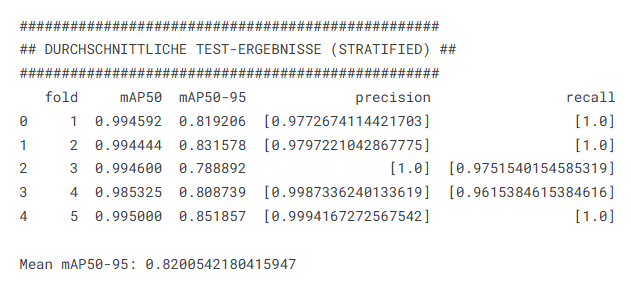

In [52]:
# Deine Ergebnisse aus der 5-Fold Cross-Validation
data_test = [
    {
        "Fold": 1,
        "Precision": [0.7514621966286971, 0.9671146226696267],
        "Recall": [0.5702702702702702, 0.9166666666666666],
        "mAP50": 0.817217,
        "mAP50-95": 0.563044,
    },
    {
        "Fold": 2,
        "Precision": [0.7385323545021348, 0.9627684545208934],
        "Recall": [0.6494995472899632, 0.9715799732608127],
        "mAP50": 0.837757,
        "mAP50-95": 0.589359,
    },
    {
        "Fold": 3,
        "Precision": [0.7381310342963431, 0.9619391630191857],
        "Recall": [0.6630434782608695, 0.9468563665758085],
        "mAP50": 0.835691,
        "mAP50-95": 0.567396,
    },
    {
        "Fold": 4,
        "Precision": [0.7367265344526664, 0.9684008740259846],
        "Recall": [0.6235435144157984, 0.9596541786743515],
        "mAP50": 0.825140,
        "mAP50-95": 0.579171,
    },
    {
        "Fold": 5,
        "Precision": [0.6915238029656346, 0.9463481568322523],
        "Recall": [0.6657824933687002, 0.976878612716763],
        "mAP50": 0.824331,
        "mAP50-95": 0.585665,
    }
]

# DataFrame erstellen
df_test = pd.DataFrame(data_test)

# Precision & Recall Listen aufsplitten: Index 0 = Defect, Index 1 = Glass
df_test['Precision_defect'] = df_test['Precision'].apply(lambda x: x[0])
df_test['Precision_glass'] = df_test['Precision'].apply(lambda x: x[1])
df_test['Recall_defect'] = df_test['Recall'].apply(lambda x: x[0])
df_test['Recall_glass'] = df_test['Recall'].apply(lambda x: x[1])

# Alte Spalten entfernen und sortieren
df_test_final = df_test.drop(columns=['Precision', "Recall"])
df_test_final = df_test_final[['Fold','Precision_defect', 'Precision_glass', 'Recall_defect', 'Recall_glass', 'mAP50', 'mAP50-95']]


col_yolo = [col for col in df_val_final if col != "Fold"]

df_test_final.style.format("{:.3f}", subset=col_yolo).hide(axis="index")



Fold,Precision_defect,Precision_glass,Recall_defect,Recall_glass,mAP50,mAP50-95
1,0.751,0.967,0.570,0.917,0.817,0.563
2,0.739,0.963,0.649,0.972,0.838,0.589
3,0.738,0.962,0.663,0.947,0.836,0.567
4,0.737,0.968,0.624,0.960,0.825,0.579
5,0.692,0.946,0.666,0.977,0.824,0.586


In [54]:
# Berechnung von Mittelwert (mean) und Standardabweichung (std)
summary_test = df_test_final.drop(columns=['Fold']).agg(['mean', 'std'])

summary_test = round(summary_test.T.rename(columns={"mean": "Mean", "std": "Std (+-)"}),3)

summary_test

,Mean,Std (+-)
Precision_defect,0.731,0.023
Precision_glass,0.961,0.009
Recall_defect,0.634,0.040
Recall_glass,0.954,0.024
mAP50,0.828,0.009
mAP50-95,0.577,0.011


RF-DETR-Roboflow Results

RF-DETR-Roboflow Val

- Fold 1

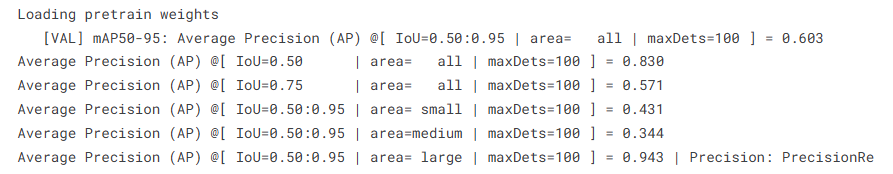

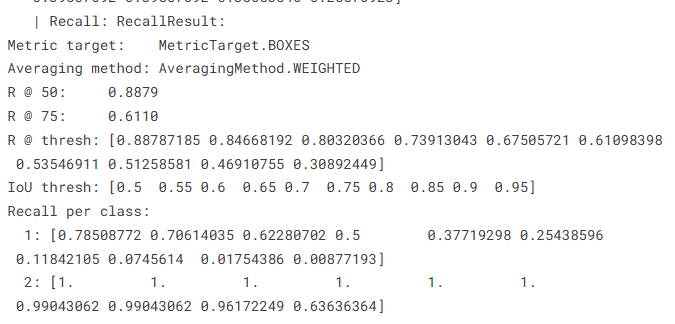

Fold	Precision
Fold 1	0.697
Fold 2	0.810

In [14]:
rfdetr_roboflow_val = [{
    "Fold": 1,
    "Precision": [0.697, np.nan],
    "Recall": [0.78508772, 1.000],
    "mAP50": 0.830,
    "mAP50-95": 0.603
},
{
    "Fold": 2,
    "Precision": [0.810, np.nan],
    "Recall": [0.85388128, 1.000],
    "mAP50": 0.886,
    "mAP50-95": 0.673
}]

# DataFrame erstellen
df_rfdetr_robo_val = pd.DataFrame(rfdetr_roboflow_val)



In [15]:

# Precision & Recall Listen aufsplitten: Index 0 = Defect, Index 1 = Glass
df_rfdetr_robo_val['Precision_defect'] = df_rfdetr_robo_val['Precision'].apply(lambda x: x[0])
df_rfdetr_robo_val['Precision_glass'] = df_rfdetr_robo_val['Precision'].apply(lambda x: x[1])
df_rfdetr_robo_val['Recall_defect'] = df_rfdetr_robo_val['Recall'].apply(lambda x: x[0])
df_rfdetr_robo_val['Recall_glass'] = df_rfdetr_robo_val['Recall'].apply(lambda x: x[1])

# Alte Spalten entfernen und sortieren
df_rfdetr_robo_val_final = df_rfdetr_robo_val.drop(columns=['Precision', 'Recall'])
df_rfdetr_robo_val_final = df_rfdetr_robo_val_final[['Fold','Precision_defect', 'Precision_glass', 'Recall_defect', 'Recall_glass', 'mAP50', 'mAP50-95', 
                      ]]



In [21]:
cols_rf = [col for col in df_rfdetr_robo_val_final if col != "Fold"]

df_rfdetr_robo_val_final.style.format("{:.3f}", subset=cols_rf).hide(axis="index")

Fold,Precision_defect,Precision_glass,Recall_defect,Recall_glass,mAP50,mAP50-95
1,0.697,nan,0.785,1.000,0.830,0.603
2,0.810,nan,0.854,1.000,0.886,0.673


In [37]:
# Berechnung von Mittelwert (mean) und Standardabweichung (std)
summary_robo_rfdetr_val_final = df_rfdetr_robo_val_final.drop(columns=['Fold']).agg(['mean', 'std'])

summary_robo_rfdetr_val_final = round(summary_robo_rfdetr_val_final.T.rename(columns={"mean": "Mean", "std": "Std (+-)"}),3)

summary_robo_rfdetr_val_final

,Mean,Std (+-)
Precision_defect,0.754,0.080
Precision_glass,NaN,NaN
Recall_defect,0.819,0.049
Recall_glass,1.000,0.000
mAP50,0.858,0.040
mAP50-95,0.638,0.049


Dataset A Val Plotting

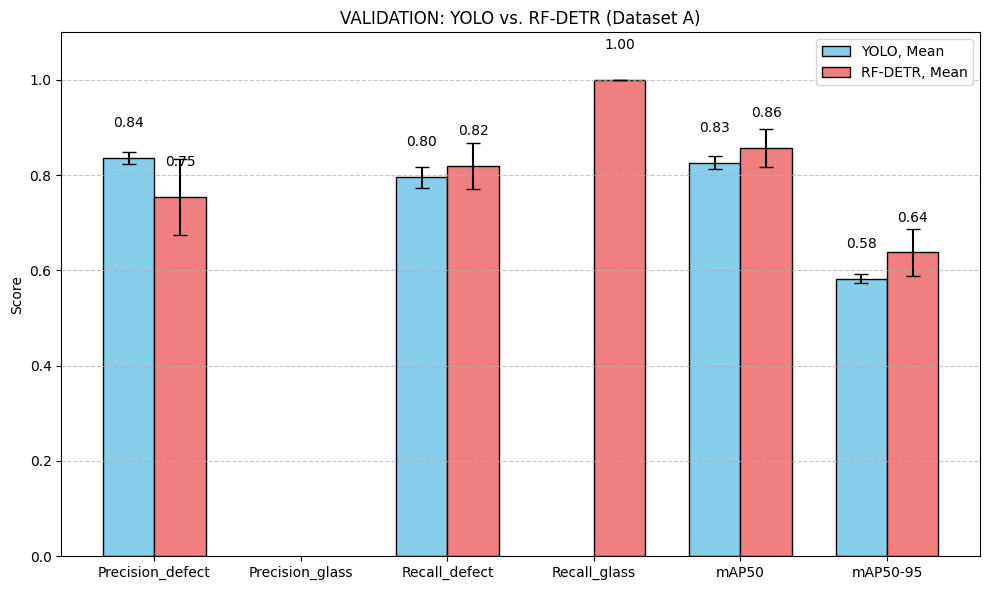

In [44]:
# 1. Daten in eine vergleichbare Struktur bringen
metrics = ['Precision_defect', 'Precision_glass', 'Recall_defect', 'Recall_glass', 'mAP50', 'mAP50-95']

df_yoloa_val = summary_yolo_val
df_rfdetra_val = summary_robo_rfdetr_val_final

# 2. Plotting vorbereiten
labels = df_yoloa_val.index
x = np.arange(len(labels))  # Position der Labels auf der X-Achse
width = 0.35  # Breite der Balken

fig, ax = plt.subplots(figsize=(10, 6))

# Balken für Modell A (mit yerr für die Fehlerbalken aus 'Std(+-)')
rects1 = ax.bar(x - width/2, df_yoloa_val["Mean"], width, label='YOLO, Mean', 
                yerr=df_yoloa_val['Std (+-)'], capsize=5, color='skyblue', edgecolor='black')

# Balken für Modell B
rects2 = ax.bar(x + width/2, df_rfdetra_val['Mean'], width, label='RF-DETR, Mean', 
                yerr=df_rfdetra_val['Std (+-)'], capsize=5, color='lightcoral', edgecolor='black')

# 3. Design und Labels anpassen
ax.set_ylabel('Score')
ax.set_title('VALIDATION: YOLO vs. RF-DETR (Dataset A)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1) # Y-Achse etwas grösser als 1.0 für die Fehlerbalken
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Werte über den Balken anzeigen (optional)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 20),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()



In [35]:
summary_robo_rfdetr_val_final

,Precision_defect,Precision_glass,Recall_defect,Recall_glass,mAP50,mAP50-95
mean,0.753500,NaN,0.819484,1.0,0.858000,0.638000
std,0.079903,NaN,0.048644,0.0,0.039598,0.049497


Fold	Precision
Fold 1	0.718
Fold 2	0.887

In [46]:
rfdetr_roboflow_test = [{
    "Fold": 1,
    "Precision": [0.718, np.nan],
    "Recall": [0.77272727, 1.000],
    "mAP50": 0.838,
    "mAP50-95": 0.599
},
{
    "Fold": 2,
    "Precision": [0.887, np.nan],
    "Recall": [0.91081081, 1.000],
    "mAP50": 0.933,
    "mAP50-95": 0.694
}]

# DataFrame erstellen
df_rfdetr_robo_test = pd.DataFrame(rfdetr_roboflow_test)

In [47]:

# Precision & Recall Listen aufsplitten: Index 0 = Defect, Index 1 = Glass
df_rfdetr_robo_test['Precision_defect'] = df_rfdetr_robo_test['Precision'].apply(lambda x: x[0])
df_rfdetr_robo_test['Precision_glass'] = df_rfdetr_robo_test['Precision'].apply(lambda x: x[1])
df_rfdetr_robo_test['Recall_defect'] = df_rfdetr_robo_test['Recall'].apply(lambda x: x[0])
df_rfdetr_robo_test['Recall_glass'] = df_rfdetr_robo_test['Recall'].apply(lambda x: x[1])

# Alte Spalten entfernen und sortieren
df_rfdetr_robo_test_final = df_rfdetr_robo_test.drop(columns=['Precision', 'Recall'])
df_rfdetr_robo_test_final = df_rfdetr_robo_test_final[['Fold','Precision_defect', 'Precision_glass', 'Recall_defect', 'Recall_glass', 'mAP50', 'mAP50-95', 
                      ]]


In [48]:
df_rfdetr_robo_test_final.style.format("{:.3f}", subset=cols_rf).hide(axis="index")

Fold,Precision_defect,Precision_glass,Recall_defect,Recall_glass,mAP50,mAP50-95
1,0.718,nan,0.773,1.000,0.838,0.599
2,0.887,nan,0.911,1.000,0.933,0.694


In [49]:
# Berechnung von Mittelwert (mean) und Standardabweichung (std)
summary_robo_rfdetr_test_final = df_rfdetr_robo_test_final.drop(columns=['Fold']).agg(['mean', 'std'])

summary_robo_rfdetr_test_final = round(summary_robo_rfdetr_test_final.T.rename(columns={"mean": "Mean", "std": "Std (+-)"}),3)

summary_robo_rfdetr_test_final

,Mean,Std (+-)
Precision_defect,0.802,0.120
Precision_glass,NaN,NaN
Recall_defect,0.842,0.098
Recall_glass,1.000,0.000
mAP50,0.886,0.067
mAP50-95,0.646,0.067


Testing_Plotting

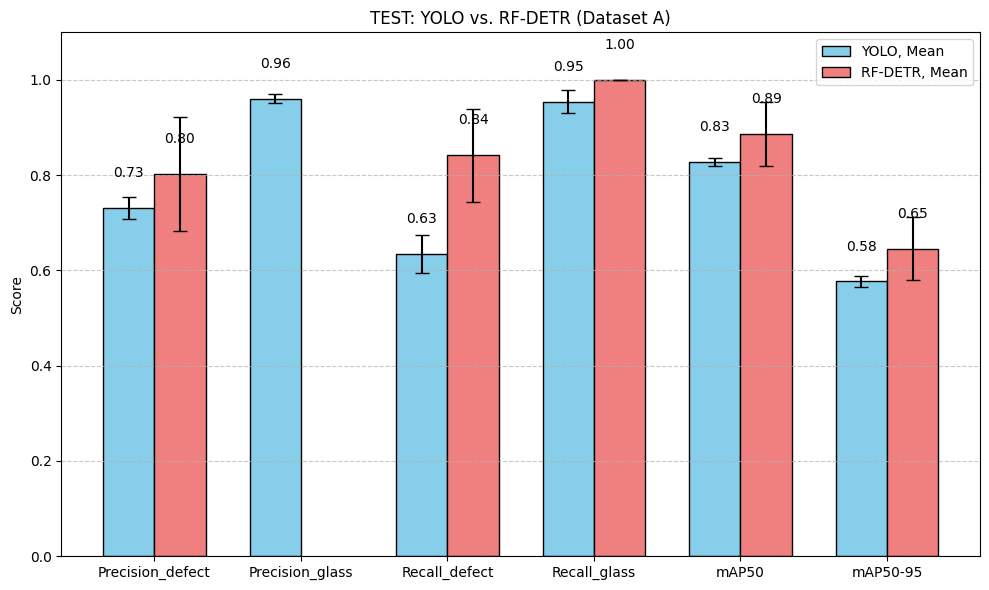

In [56]:
# 1. Daten in eine vergleichbare Struktur bringen
metrics = ['Precision_defect', 'Precision_glass', 'Recall_defect', 'Recall_glass', 'mAP50', 'mAP50-95']

df_yoloa_test = summary_test
df_rfdetra_test = summary_robo_rfdetr_test_final

# 2. Plotting vorbereiten
labels = df_yoloa_test.index
x = np.arange(len(labels))  # Position der Labels auf der X-Achse
width = 0.35  # Breite der Balken

fig, ax = plt.subplots(figsize=(10, 6))

# Balken für Modell A (mit yerr für die Fehlerbalken aus 'Std(+-)')
rects1 = ax.bar(x - width/2, df_yoloa_test["Mean"], width, label='YOLO, Mean', 
                yerr=df_yoloa_test['Std (+-)'], capsize=5, color='skyblue', edgecolor='black')

# Balken für Modell B
rects2 = ax.bar(x + width/2, df_rfdetra_test['Mean'], width, label='RF-DETR, Mean', 
                yerr=df_rfdetra_test['Std (+-)'], capsize=5, color='lightcoral', edgecolor='black')

# 3. Design und Labels anpassen
ax.set_ylabel('Score')
ax.set_title('TEST: YOLO vs. RF-DETR (Dataset A)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1) # Y-Achse etwas grösser als 1.0 für die Fehlerbalken
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Werte über den Balken anzeigen (optional)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 20),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 2x2 Matrix Data ---
# Classes: 0=defect, 1=Background

# Row 0 (True: defect)

row_defect = [50, 1] 

# Row 1 (True: glass)

row_glass = [0, 0] 


cm_2x2_data = np.array([
    row_defect, 
    row_glass, 
])

labels_2x2 = ['DEFECT', 'no defect']


# --- 2. Plot the 2x2 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_2x2_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_2x2,
    yticklabels=labels_2x2
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Kaggle Fold 5')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 2x2 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_2x2_data, index=labels_2x2, columns=labels_2x2)
print(df)

RF-DETR Kaggle Val Prec

In [9]:
import pandas as pd

TP=[31, 28, 28, 29, 32]
TN=[0, 0, 0, 0, 0]
FP=[0, 0, 0, 0, 0]
FN=[0, 0, 0, 0 , 0]

folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

# A list to store the results for each fold
results_per_fold = []

# Unpack the tuple from zip into meaningful variable names
for fold_name, tp_val, tn_val, fp_val, fn_val in zip(folds, TP, TN, FP, FN):
    # Handle division by zero for precision
    if (tp_val + fp_val) == 0:
        precision_rfdetr = 0.0
    else:
        precision_rfdetr = tp_val / (tp_val + fp_val)

    # Handle division by zero for recall
    if (tp_val + fn_val) == 0:
        recall_rfdetr = 0.0
    else:
        recall_rfdetr = tp_val / (tp_val + fn_val)
    
    # Handle division by zero for F1 score
    if (precision_rfdetr + recall_rfdetr) == 0:
        f1_rfdetr = 0.0
    else:
        f1_rfdetr = 2 * (precision_rfdetr * recall_rfdetr) / (precision_rfdetr + recall_rfdetr)
    
    # Create a dictionary for the current fold's results
    fold_results = {
        "Fold": fold_name,
        "Precision": precision_rfdetr,
        # "Recall": recall_rfdetr,
        # "F1": f1_rfdetr,
        # "mAP50": map50_val,
        # "mAP50-95": map5095_val
    }
    
    # Add the dictionary to our list of results
    results_per_fold.append(fold_results)

numeric_cols = [col for col in fold_results.keys() if col != "Fold"]

# Create a DataFrame from the list of dictionaries for a nice display
df_results = pd.DataFrame(results_per_fold)
# Werte aus den Listen extrahieren (da nur 1 Klasse/Wert vorhanden ist)
# df_results['Precision'] = df_results['Precision'].apply(lambda x: x[0])
# df_results['recall'] = df_results['recall'].apply(lambda x: x[0])

# Zusammenfassung berechnen
summary_rfdetr_kaggle_prec_val = df_results.drop(columns=['Fold']).agg(['mean', 'std'])


round(summary_rfdetr_kaggle_prec_val.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

# df_results.style.format('{:.3f}', subset=numeric_cols).hide(axis="index")


,Mean,Std +-
Precision,1.0,0.0


RF-DETR-Kaggle Prec Test

In [28]:
TP=[53, 48, 49, 47, 50]
TN=[0, 0, 0, 0, 0]
FP=[1, 0, 0, 0, 0]
FN=[0, 0, 0, 0 , 1]

folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

# A list to store the results for each fold
results_per_fold_test = []

# Unpack the tuple from zip into meaningful variable names
for fold_name, tp_val, tn_val, fp_val, fn_val in zip(folds, TP, TN, FP, FN):
    # Handle division by zero for precision
    if (tp_val + fp_val) == 0:
        precision_rfdetr = 0.0
    else:
        precision_rfdetr = tp_val / (tp_val + fp_val)

    # Handle division by zero for recall
    if (tp_val + fn_val) == 0:
        recall_rfdetr = 0.0
    else:
        recall_rfdetr = tp_val / (tp_val + fn_val)
    
    # Handle division by zero for F1 score
    if (precision_rfdetr + recall_rfdetr) == 0:
        f1_rfdetr = 0.0
    else:
        f1_rfdetr = 2 * (precision_rfdetr * recall_rfdetr) / (precision_rfdetr + recall_rfdetr)
    
    # Create a dictionary for the current fold's results
    fold_results = {
        "Fold": fold_name,
        "Precision": precision_rfdetr,
        # "Recall": recall_rfdetr,
        # "F1": f1_rfdetr,
        # "mAP50": map50_val,
        # "mAP50-95": map5095_val
    }
    
    # Add the dictionary to our list of results
    results_per_fold_test.append(fold_results)

numeric_cols = [col for col in fold_results.keys() if col != "Fold"]

# Create a DataFrame from the list of dictionaries for a nice display
df_results = pd.DataFrame(results_per_fold_test)

# summary_rfdetr_kaggle_prec_test = df_results.drop(columns=['Fold']).agg(['mean', 'std'])


# round(summary_rfdetr_kaggle_prec_test.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

df_results.style.format('{:.3f}', subset=numeric_cols).hide(axis="index")


Fold,Precision
Fold 1,0.981
Fold 2,1.000
Fold 3,1.000
Fold 4,1.000
Fold 5,1.000


RF-DETR-Roboflow Prec-Val

In [106]:
TP=[159, 170]
TN=[208, 208]
FP=[69, 40]
FN=[69, 49]

folds = ["Fold 1", "Fold 2"]

# A list to store the results for each fold
results_per_fold_test = []

# Unpack the tuple from zip into meaningful variable names
for fold_name, tp_val, tn_val, fp_val, fn_val in zip(folds, TP, TN, FP, FN):
    # Handle division by zero for precision
    if (tp_val + fp_val) == 0:
        precision_rfdetr = 0.0
    else:
        precision_rfdetr = tp_val / (tp_val + fp_val)

    # Handle division by zero for recall
    if (tp_val + fn_val) == 0:
        recall_rfdetr = 0.0
    else:
        recall_rfdetr = tp_val / (tp_val + fn_val)
    
    # Handle division by zero for F1 score
    if (precision_rfdetr + recall_rfdetr) == 0:
        f1_rfdetr = 0.0
    else:
        f1_rfdetr = 2 * (precision_rfdetr * recall_rfdetr) / (precision_rfdetr + recall_rfdetr)
    
    # Create a dictionary for the current fold's results
    fold_results = {
        "Fold": fold_name,
        "Precision": precision_rfdetr,
        # "Recall": recall_rfdetr,
        # "F1": f1_rfdetr,
        # "mAP50": map50_val,
        # "mAP50-95": map5095_val
    }
    
    # Add the dictionary to our list of results
    results_per_fold_test.append(fold_results)

numeric_cols = [col for col in fold_results.keys() if col != "Fold"]

# Create a DataFrame from the list of dictionaries for a nice display
df_results = pd.DataFrame(results_per_fold_test)

# summary_rfdetr_kaggle_prec_test = df_results.drop(columns=['Fold']).agg(['mean', 'std'])


# round(summary_rfdetr_kaggle_prec_test.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

df_results.style.format('{:.3f}', subset=numeric_cols).hide(axis="index")


Fold,Precision
Fold 1,0.697
Fold 2,0.810


RF-DETR-Roboflow Prec-Test

In [105]:
TP=[265, 323]
TN=[347, 346]
FP=[104, 41]
FN=[109, 47]

folds = ["Fold 1", "Fold 2"]

# A list to store the results for each fold
results_per_fold_test = []

# Unpack the tuple from zip into meaningful variable names
for fold_name, tp_val, tn_val, fp_val, fn_val in zip(folds, TP, TN, FP, FN):
    # Handle division by zero for precision
    if (tp_val + fp_val) == 0:
        precision_rfdetr = 0.0
    else:
        precision_rfdetr = tp_val / (tp_val + fp_val)

    # Handle division by zero for recall
    if (tp_val + fn_val) == 0:
        recall_rfdetr = 0.0
    else:
        recall_rfdetr = tp_val / (tp_val + fn_val)
    
    # Handle division by zero for F1 score
    if (precision_rfdetr + recall_rfdetr) == 0:
        f1_rfdetr = 0.0
    else:
        f1_rfdetr = 2 * (precision_rfdetr * recall_rfdetr) / (precision_rfdetr + recall_rfdetr)
    
    # Create a dictionary for the current fold's results
    fold_results = {
        "Fold": fold_name,
        "Precision": precision_rfdetr,
        # "Recall": recall_rfdetr,
        # "F1": f1_rfdetr,
        # "mAP50": map50_val,
        # "mAP50-95": map5095_val
    }
    
    # Add the dictionary to our list of results
    results_per_fold_test.append(fold_results)

numeric_cols = [col for col in fold_results.keys() if col != "Fold"]

# Create a DataFrame from the list of dictionaries for a nice display
df_results = pd.DataFrame(results_per_fold_test)

# summary_rfdetr_kaggle_prec_test = df_results.drop(columns=['Fold']).agg(['mean', 'std'])


# round(summary_rfdetr_kaggle_prec_test.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

df_results.style.format('{:.3f}', subset=numeric_cols).hide(axis="index")


Fold,Precision
Fold 1,0.718
Fold 2,0.887


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 3x3 Matrix Data ---
# Classes: 0=defect, 1=glass, 2=Background

# Row 0 (True: defect)
# P: defect (141), P: glass (1), P: Background (FN = 55)
row_defect = [141, 1, 55] 

# Row 1 (True: glass)
# P: defect (50), P: glass (173), P: Background (FN for glass, assumed 0)
row_glass = [0, 173, 0] 

# Row 2 (True: Background)
# P: defect (FP = 50), P: glass (FP for glass, assumed 0), P: Background (TN, assumed 0)
row_background = [50, 0, 0]

cm_3x3_data = np.array([
    row_defect, 
    row_glass, 
    row_background
])

labels_3x3 = ['defect', 'glass', 'no defect']


# --- 2. Plot the 3x3 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_3x3_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_3x3,
    yticklabels=labels_3x3
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Roboflow')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 3x3 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_3x3_data, index=labels_3x3, columns=labels_3x3)
print(df)